In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Montpellier"
away= "Rennes"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Montpellier,Toulouse,2025-01-26,W,A,2,1,1,34,0,...,0.4,0.4,1.5,1.5,0.6,0.09,0,0.8,0.16,-0.2
19,Montpellier,Lens,2025-01-31,L,H,0,2,-2,49,0,...,0.7,0.8,-0.8,-0.8,-0.7,0.06,1,2.0,0.39,0.0
20,Montpellier,Strasbourg,2025-02-09,L,A,0,2,-2,41,0,...,1.8,1.1,-1.8,-1.8,-1.8,0.17,1,1.7,0.40,-0.3
21,Montpellier,Lyon,2025-02-16,L,H,1,4,-3,38,0,...,1.2,1.1,-0.4,-0.4,-0.2,0.13,1,2.8,0.46,-1.2
22,Montpellier,Nice,2025-02-23,L,A,0,2,-2,44,0,...,0.4,0.5,-0.6,-0.6,-0.4,0.04,1,1.5,0.26,-0.5


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Toulouse,Montpellier,2025-01-26,L,H,1,2,-1,66,0,...,1.0,1.6,0.0,0.0,0.0,0.07,0,2.2,0.54,0.2
19,Lens,Montpellier,2025-01-31,W,A,2,0,2,51,0,...,1.7,0.8,0.0,0.0,0.3,0.11,1,0.4,0.21,0.4
20,Strasbourg,Montpellier,2025-02-09,W,H,2,0,2,59,0,...,1.7,1.6,-0.7,-0.7,-0.7,0.14,1,0.1,0.06,0.1
21,Lyon,Montpellier,2025-02-16,W,A,4,1,3,62,0,...,1.0,1.1,3.0,3.0,3.0,0.11,0,1.2,0.31,0.2
22,Nice,Montpellier,2025-02-23,W,H,2,0,2,56,0,...,1.7,2.1,0.2,0.2,0.3,0.11,0,0.0,0.04,0.0


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Rennes,Monaco,2025-01-25,L,A,2,3,-1,48,0,...,1.2,0.8,0.2,0.2,-0.2,0.13,0,3.6,0.40,0.6
19,Rennes,Strasbourg,2025-02-02,W,H,1,0,1,46,0,...,0.7,0.7,0.1,0.1,-0.7,0.07,0,0.7,0.25,0.7
20,Rennes,Saint-Étienne,2025-02-08,W,A,2,0,2,47,0,...,2.3,1.5,-1.6,-1.6,-1.3,0.18,0,0.4,0.12,0.4
21,Rennes,Lille,2025-02-16,L,H,0,2,-2,37,0,...,0.2,0.2,-0.4,-0.4,-0.2,0.11,0,2.5,0.35,0.5
22,Rennes,Reims,2025-02-21,W,H,1,0,1,58,1,...,1.5,2.0,-1.3,-1.6,-1.5,0.06,0,0.0,NaN,0.0


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Monaco,Rennes,2025-01-25,W,H,3,2,1,52,0,...,2.9,1.9,-0.5,-0.5,0.1,0.19,0,1.5,0.32,-0.5
19,Strasbourg,Rennes,2025-02-02,L,A,0,1,-1,54,0,...,1.2,0.8,-1.2,-1.2,-1.2,0.17,0,1.2,0.41,0.2
20,Saint-Étienne,Rennes,2025-02-08,L,H,0,2,-2,53,0,...,0.5,1.1,-0.5,-0.5,-0.5,0.05,0,2.8,0.35,0.8
21,Lille,Rennes,2025-02-16,W,A,2,0,2,63,1,...,1.7,1.6,-1.0,-0.4,-0.7,0.15,1,0.0,NaN,0.0
22,Reims,Rennes,2025-02-21,L,A,0,1,-1,42,0,...,0.1,0.4,-0.1,-0.1,-0.1,0.04,0,2.8,0.37,1.8


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,2,0,0,34,0,14,5,35.7,9,64.3,...,-0.4,-0.4,0.4,0.4,1.5,1.5,0.6,0.09,0,2
19,0,0,0,49,0,22,11,50.0,8,36.4,...,-1.2,-1.2,0.7,0.8,-0.8,-0.8,-0.7,0.06,1,0
20,0,0,0,41,0,15,9,60.0,5,33.3,...,-1.0,-1.0,1.8,1.1,-1.8,-1.8,-1.8,0.17,1,0
21,1,0,0,38,0,16,12,75.0,4,25.0,...,0.4,0.4,1.2,1.1,-0.4,-0.4,-0.2,0.13,1,1
22,0,0,0,44,0,7,4,57.1,2,28.6,...,-1.2,-1.2,0.4,0.5,-0.6,-0.6,-0.4,0.04,1,0


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,66,0,21,13,61.9,7,33.3,...,0.4,0.4,1.0,1.6,0.0,0.0,0.0,0.07,0,1
19,2,0,0,51,0,20,11,55.0,8,40.0,...,1.2,1.2,1.7,0.8,0.0,0.0,0.3,0.11,1,2
20,2,0,0,59,0,18,9,50.0,8,44.4,...,1.0,1.0,1.7,1.6,-0.7,-0.7,-0.7,0.14,1,2
21,4,0,0,62,0,12,5,41.7,5,41.7,...,-0.4,-0.4,1.0,1.1,3.0,3.0,3.0,0.11,0,4
22,2,0,0,56,0,21,9,42.9,12,57.1,...,1.2,1.2,1.7,2.1,0.2,0.2,0.3,0.11,0,2


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,2,0,0,48,0,22,8,36.4,12,54.5,...,-1.7,-1.7,1.2,0.8,0.2,0.2,-0.2,0.13,0,2
19,1,0,0,46,0,13,6,46.2,6,46.2,...,-0.3,-0.3,0.7,0.7,0.1,0.1,-0.7,0.07,0,1
20,2,0,0,47,0,24,15,62.5,7,29.2,...,3.1,3.1,2.3,1.5,-1.6,-1.6,-1.3,0.18,0,2
21,0,0,0,37,0,16,6,37.5,8,50.0,...,-2.6,-1.9,0.2,0.2,-0.4,-0.4,-0.2,0.11,0,0
22,0,1,0,58,1,21,8,38.1,12,57.1,...,2.2,1.5,1.5,2.0,-1.3,-1.6,-1.5,0.06,0,1


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,3,0,0,52,0,15,8,53.3,6,40.0,...,1.7,1.7,2.9,1.9,-0.5,-0.5,0.1,0.19,0,3
19,0,0,0,54,0,18,7,38.9,10,55.6,...,0.3,0.3,1.2,0.8,-1.2,-1.2,-1.2,0.17,0,0
20,0,0,0,53,0,14,5,35.7,8,57.1,...,-3.1,-3.1,0.5,1.1,-0.5,-0.5,-0.5,0.05,0,0
21,2,0,1,63,1,15,8,53.3,7,46.7,...,2.6,1.9,1.7,1.6,-1.0,-0.4,-0.7,0.15,1,2
22,0,0,0,42,0,11,4,36.4,6,54.5,...,-2.2,-1.5,0.1,0.4,-0.1,-0.1,-0.1,0.04,0,0


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,18,1,5.6,0,1,12.2,0,NaN,0,0,...,5,8,17,38,39,0,0.8,0.16,-0.2,1
19,18,0,0.0,0,2,23.4,0,NaN,0,0,...,6,9,6,26,39,0,2.0,0.39,0.0,2
20,23,1,4.3,0,1,9.7,0,NaN,0,0,...,7,4,4,21,21,4,1.7,0.40,-0.3,2
21,6,0,0.0,0,0,NaN,0,NaN,0,0,...,2,13,9,22,17,0,2.8,0.46,-1.2,4
22,11,1,9.1,0,1,11.0,0,NaN,0,0,...,4,6,6,27,26,1,1.5,0.26,-0.5,2


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,5,0,0.0,0,2,20.7,0,NaN,0,0,...,1,8,5,21,26,2,2.2,0.54,0.2,2
19,17,3,17.6,0,0,10.0,0,NaN,0,0,...,2,14,12,27,29,1,0.4,0.21,0.4,0
20,11,1,9.1,0,0,7.3,0,NaN,0,0,...,1,4,13,30,21,0,0.1,0.06,0.1,0
21,20,2,10.0,0,0,4.7,0,NaN,0,0,...,4,4,5,12,35,1,1.2,0.31,0.2,1
22,13,2,15.4,0,1,10.5,0,NaN,0,0,...,6,11,12,23,33,0,0.0,0.04,0.0,0


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,15,0,0.0,1,0,NaN,1,100.0,0,0,...,6,8,11,33,26,0,0.7,0.05,0.7,0
1,7,0,0.0,0,0,2.0,0,NaN,0,1,...,3,9,11,30,10,0,1.4,0.28,-0.6,3
2,12,0,0.0,0,0,10.0,0,NaN,0,0,...,1,9,5,26,23,0,1.6,0.22,-0.4,2
3,12,1,8.3,0,0,8.5,0,NaN,0,0,...,4,2,5,20,20,0,0.2,0.04,0.2,0
4,16,2,12.5,0,2,12.2,0,NaN,0,0,...,5,7,15,35,29,0,0.7,0.33,-0.3,1


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,9,0,0.0,0,4,22.2,0,NaN,1,0,...,4,4,13,35,22,1,2.6,0.33,-0.4,3
1,13,0,0.0,0,3,12.0,0,NaN,0,0,...,3,4,7,28,27,0,1.0,0.21,0.0,1
2,12,0,0.0,0,1,17.0,0,NaN,0,1,...,5,10,8,24,18,1,1.1,0.22,0.1,1
3,16,1,6.3,0,2,17.8,0,NaN,0,0,...,0,4,15,38,21,1,2.0,0.33,-1.0,3
4,8,2,25.0,1,1,9.2,0,0.0,0,0,...,1,14,7,19,19,0,1.4,0.08,0.4,1


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,15,10,60.0,2,0,0,15,8,45
19,18,15,54.5,4,0,0,12,17,50
20,10,14,41.7,4,0,0,12,11,44
21,11,10,52.4,3,0,0,14,9,37
22,19,27,41.3,1,0,0,15,17,41


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,10,15,40.0,1,0,0,9,12,51
19,15,18,45.5,3,0,0,17,11,45
20,14,10,58.3,1,0,0,12,12,47
21,10,11,47.6,1,0,0,12,13,21
22,27,19,58.7,1,0,0,17,15,48


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,20,14,58.8,3,0,0,16,10,43
19,9,16,36.0,3,0,0,14,9,41
20,8,15,34.8,5,0,0,6,13,51
21,8,15,34.8,2,1,0,9,16,35
22,15,5,75.0,1,0,0,15,6,35


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,14,20,41.2,3,0,0,12,16,51
19,16,9,64.0,3,0,0,10,13,36
20,15,8,65.2,1,0,0,13,6,54
21,15,8,65.2,1,0,0,18,8,47
22,5,15,25.0,2,2,1,7,15,24


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,2,0,0,34,0,14,5,35.7,9,64.3,...,-0.500,0.503322,-0.400,0.416333,0.1050,0.064550,0.75,0.957427,1.25,0.957427
19,0,0,0,49,0,22,11,50.0,8,36.4,...,-0.125,1.147098,-0.275,0.634429,0.1050,0.064550,0.75,0.957427,1.25,0.957427
20,0,0,0,41,0,15,9,60.0,5,33.3,...,-0.025,1.034005,-0.225,0.573730,0.1025,0.066521,0.75,0.957427,1.25,0.957427
21,1,0,0,38,0,16,12,75.0,4,25.0,...,-0.375,1.381726,-0.600,0.983192,0.1300,0.065828,1.00,0.816497,1.00,1.154701
22,0,0,0,44,0,7,4,57.1,2,28.6,...,-0.375,1.381726,-0.525,1.004573,0.1125,0.047871,0.75,0.500000,0.75,0.957427


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,66,0,21,13,61.9,7,33.3,...,-0.600,0.848528,-0.175,0.977667,0.1125,0.049917,0.25,0.50000,1.75,0.957427
19,2,0,0,51,0,20,11,55.0,8,40.0,...,-0.750,0.574456,-0.475,0.464579,0.1100,0.052281,0.00,0.00000,1.50,1.000000
20,2,0,0,59,0,18,9,50.0,8,44.4,...,-0.400,0.461880,-0.275,0.602080,0.1075,0.051881,0.25,0.50000,1.75,0.957427
21,4,0,0,62,0,12,5,41.7,5,41.7,...,-0.375,0.434933,-0.175,0.427200,0.0975,0.034034,0.50,0.57735,1.50,0.577350
22,2,0,0,56,0,21,9,42.9,12,57.1,...,0.575,1.650000,0.650,1.621727,0.1075,0.028723,0.50,0.57735,2.25,1.258306


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,11,0,0.0,0,2,13.9,0,0.0,0,0,...,0.75,0.500000,1.325,1.030776,0.3400,0.040000,-0.425,0.750000,1.75,1.258306
19,14,1,7.1,0,2,16.6,0,0.0,0,0,...,1.25,0.500000,2.225,1.059481,0.3550,0.044347,-0.275,0.906918,2.50,0.577350
20,11,1,9.1,0,0,7.0,0,0.0,0,0,...,1.00,0.816497,1.950,1.317826,0.3425,0.066521,0.200,0.743864,1.75,1.258306
21,19,1,5.3,1,0,6.0,1,100.0,0,1,...,0.75,0.957427,1.450,1.461734,0.2875,0.129968,0.200,0.743864,1.25,1.500000
22,6,0,0.0,0,1,18.5,0,0.0,0,0,...,0.75,0.957427,1.800,1.516575,0.2800,0.123558,0.550,0.129099,1.25,1.500000


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,11,0,0.0,0,0,0.0,0,0.0,0,0,...,0.75,0.50000,1.725,0.537742,0.3300,0.121929,0.225,0.767572,1.50,0.577350
19,17,1,5.9,0,0,4.0,0,0.0,0,1,...,0.50,0.57735,1.825,0.403113,0.3425,0.116154,0.325,0.573730,1.50,0.577350
20,13,0,0.0,0,0,4.7,0,0.0,0,0,...,0.50,0.57735,1.525,0.250000,0.3250,0.091104,0.275,0.573730,1.25,0.500000
21,12,0,0.0,0,2,16.8,0,0.0,0,0,...,0.50,0.57735,1.825,0.694622,0.3200,0.088318,0.325,0.618466,1.50,0.577350
22,23,1,4.3,1,0,8.3,0,0.0,0,0,...,0.25,0.50000,1.375,1.150000,0.3600,0.045826,0.125,0.537742,1.25,0.957427


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,2,0,0,48,0,22,8,36.4,12,54.5,...,3.500000e-01,0.785281,0.275,0.434933,0.1300,0.064807,0.0,0.0,1.50,0.577350
19,1,0,0,46,0,13,6,46.2,6,46.2,...,5.000000e-02,0.369685,0.100,0.454606,0.1425,0.056199,0.0,0.0,1.50,0.577350
20,2,0,0,47,0,24,15,62.5,7,29.2,...,6.938894e-18,0.336650,-0.125,0.590903,0.1175,0.061847,0.0,0.0,1.25,0.500000
21,0,0,0,37,0,16,6,37.5,8,50.0,...,-4.500000e-01,0.826640,-0.625,0.499166,0.1125,0.053151,0.0,0.0,1.50,0.577350
22,0,1,0,58,1,21,8,38.1,12,57.1,...,-4.250000e-01,0.826136,-0.600,0.522813,0.1225,0.045735,0.0,0.0,1.25,0.957427


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,3,0,0,52,0,15,8,53.3,6,40.0,...,0.600,0.828654,0.700,0.820569,0.1300,0.029439,0.25,0.5,1.75,1.258306
19,0,0,0,54,0,18,7,38.9,10,55.6,...,0.575,0.869387,0.825,0.607591,0.1475,0.040311,0.25,0.5,2.50,0.577350
20,0,0,0,53,0,14,5,35.7,8,57.1,...,-0.100,0.955685,0.250,1.126943,0.1475,0.040311,0.25,0.5,1.75,1.258306
21,2,0,1,63,1,15,8,53.3,7,46.7,...,-0.300,0.927362,-0.025,1.147098,0.1275,0.064485,0.00,0.0,1.25,1.500000
22,0,0,0,42,0,11,4,36.4,6,54.5,...,-0.650,0.369685,-0.575,0.537742,0.1400,0.062183,0.25,0.5,1.25,1.500000


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,18,1,5.6,0,1,12.2,0,0.0,0,0,...,1.00,1.414214,2.450,1.586401,0.4125,0.121484,0.950,0.806226,1.75,0.957427
19,18,0,0.0,0,2,23.4,0,0.0,0,0,...,1.00,1.414214,2.125,1.800694,0.3675,0.177647,0.875,0.917878,1.50,1.000000
20,23,1,4.3,0,1,9.7,0,0.0,0,0,...,1.00,1.414214,2.500,1.476482,0.3400,0.157692,0.750,1.014889,1.75,0.957427
21,6,0,0.0,0,0,0.0,0,0.0,0,0,...,1.25,1.892969,1.850,0.866025,0.3075,0.112361,0.350,1.040833,1.50,0.577350
22,11,1,9.1,0,1,11.0,0,0.0,0,0,...,1.00,2.000000,1.825,0.826136,0.3525,0.132004,-0.425,0.531507,2.25,1.258306


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,5,0,0.0,0,2,20.7,0,0.0,0,0,...,1.00,0.816497,1.275,0.537742,0.2000,0.146969,0.025,0.434933,1.25,0.957427
19,17,3,17.6,0,0,10.0,0,0.0,0,0,...,1.25,0.957427,1.375,0.684957,0.2800,0.226863,0.125,0.411299,1.25,0.957427
20,11,1,9.1,0,0,7.3,0,0.0,0,0,...,1.25,0.957427,1.325,0.763217,0.3075,0.203204,0.075,0.340343,1.25,0.957427
21,20,2,10.0,0,0,4.7,0,0.0,0,0,...,1.25,0.957427,1.075,0.991211,0.3025,0.210772,0.075,0.340343,1.00,1.154701
22,13,2,15.4,0,1,10.5,0,0.0,0,0,...,1.00,0.816497,0.975,0.939415,0.2800,0.201494,0.225,0.125831,0.75,0.957427


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
18,15,10,60.0,2,0,0,15,8,45,15.00,...,0.5,1.0,0.25,0.5,10.75,3.304038,10.75,2.629956,43.75,1.258306
19,18,15,54.5,4,0,0,12,17,50,15.25,...,0.5,1.0,0.25,0.5,10.75,3.304038,9.50,2.380476,44.00,1.414214
20,10,14,41.7,4,0,0,12,11,44,17.25,...,0.5,1.0,0.25,0.5,11.25,3.304038,11.75,4.112988,46.00,2.708013
21,11,10,52.4,3,0,0,14,9,37,16.50,...,0.0,0.0,0.00,0.0,11.50,3.316625,11.25,4.031129,46.00,2.708013
22,19,27,41.3,1,0,0,15,17,41,13.50,...,0.0,0.0,0.00,0.0,13.25,1.500000,11.25,4.031129,44.00,5.354126


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
18,10,15,40.0,1,0,0,9,12,51,15.25,...,0.0,0.0,0.0,0.0,11.25,3.304038,10.75,3.304038,48.00,5.597619
19,15,18,45.5,3,0,0,17,11,45,14.25,...,0.0,0.0,0.0,0.0,10.25,3.201562,10.00,2.160247,49.75,4.991660
20,14,10,58.3,1,0,0,12,12,47,15.00,...,0.0,0.0,0.0,0.0,12.50,4.123106,10.25,2.217356,48.50,5.507571
21,10,11,47.6,1,0,0,12,13,21,14.75,...,0.0,0.0,0.0,0.0,11.75,3.774917,10.50,2.380476,49.50,4.434712
22,27,19,58.7,1,0,0,17,15,48,12.25,...,0.0,0.0,0.0,0.0,12.50,3.316625,12.00,0.816497,41.00,13.564660


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
18,20,14,58.8,3,0,0,16,10,43,15.00,...,0.00,0.0,0.0,0.0,14.00,2.943920,11.00,0.816497,47.50,3.872983
19,9,16,36.0,3,0,0,14,9,41,17.50,...,0.00,0.0,0.0,0.0,13.50,2.081666,10.75,0.957427,47.25,4.193249
20,8,15,34.8,5,0,0,6,13,51,16.50,...,0.00,0.0,0.0,0.0,13.50,2.081666,10.50,1.290994,46.00,5.291503
21,8,15,34.8,2,1,0,9,16,35,16.50,...,0.00,0.0,0.0,0.0,12.25,4.349329,10.75,1.707825,47.00,5.887841
22,15,5,75.0,1,0,0,15,6,35,11.25,...,0.25,0.5,0.0,0.0,11.25,4.573474,12.00,3.162278,42.50,6.608076


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
18,14,20,41.2,3,0,0,12,16,51,10.25,...,0.25,0.5,0.0,0.0,11.75,0.957427,13.75,2.986079,45.25,1.892969
19,16,9,64.0,3,0,0,10,13,36,11.25,...,0.25,0.5,0.0,0.0,11.75,0.957427,13.25,2.061553,47.00,3.162278
20,15,8,65.2,1,0,0,13,6,54,13.00,...,0.00,0.0,0.0,0.0,11.50,1.290994,13.25,2.061553,44.00,6.164414
21,15,8,65.2,1,0,0,18,8,47,14.75,...,0.00,0.0,0.0,0.0,11.50,1.290994,12.00,4.242641,46.50,7.937254
22,5,15,25.0,2,2,1,7,15,24,15.00,...,0.00,0.0,0.0,0.0,13.25,3.403430,10.75,4.573474,47.00,7.874008


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,0,0,0,44,0,7,4,57.1,2,28.6,...,0.957427,1.8,1.516575,0.28,0.123558,0.55,0.129099,1.25,1.5,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,1,0,42,1,14,3,21.4,10,71.4,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.0,0.000000,A,0
1,0,0,0,32,0,13,3,23.1,8,61.5,...,0.0,0.0,13.00,0.000000,11.000000,0.000000,47.0,0.000000,H,1
2,1,0,0,69,0,28,10,35.7,16,57.1,...,0.0,0.0,16.00,4.242641,10.000000,1.414214,47.0,0.000000,A,0
3,0,0,0,49,0,17,9,52.9,7,41.2,...,0.0,0.0,15.00,3.464102,9.333333,1.527525,43.0,6.928203,H,3
4,3,0,0,54,0,17,10,58.8,7,41.2,...,0.0,0.0,13.75,3.774917,8.750000,1.707825,43.0,5.656854,A,1


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,11,1,9.1,0,1,11.0,0,0.0,0,0,...,0.5,0.0,0.0,11.25,4.573474,12.0,3.162278,42.5,6.608076,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,9,0,0.0,0,2,17.8,0,0.0,0,0,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.0,0.000000,A,6
1,11,1,9.1,0,0,8.8,0,0.0,0,0,...,0.0,0.0,13.00,0.000000,11.000000,0.000000,47.0,0.000000,H,3
2,9,1,11.1,1,2,19.4,0,0.0,0,0,...,0.0,0.0,16.00,4.242641,10.000000,1.414214,47.0,0.000000,A,3
3,16,1,6.3,0,2,17.8,0,0.0,0,0,...,0.0,0.0,15.00,3.464102,9.333333,1.527525,43.0,6.928203,H,2
4,16,1,6.3,0,0,10.0,0,0.0,0,0,...,0.0,0.0,13.75,3.774917,8.750000,1.707825,43.0,5.656854,A,2


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,0,1,0,58,1,21,8,38.1,12,57.1,...,0.5,0.0,0.0,11.25,4.573474,12.0,3.162278,42.5,6.608076,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,3,0,0,47,0,15,6,40.0,7,46.7,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.0,0.000000,A,1
1,1,0,0,41,0,20,6,30.0,14,70.0,...,0.0,0.0,13.00,0.000000,11.000000,0.000000,47.0,0.000000,A,1
2,1,0,0,47,0,14,7,50.0,6,42.9,...,0.0,0.0,16.00,4.242641,10.000000,1.414214,47.0,0.000000,H,3
3,3,0,0,51,0,28,14,50.0,13,46.4,...,0.0,0.0,15.00,3.464102,9.333333,1.527525,43.0,6.928203,H,1
4,0,1,0,40,1,10,3,30.0,6,60.0,...,0.0,0.0,13.75,3.774917,8.750000,1.707825,43.0,5.656854,A,1


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,6,0,0.0,0,1,18.5,0,0.0,0,0,...,0.5,0.0,0.0,11.25,4.573474,12.0,3.162278,42.5,6.608076,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,15,0,0.0,1,0,0.0,1,100.0,0,0,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.0,0.000000,A,3
1,7,0,0.0,0,0,2.0,0,0.0,0,1,...,0.0,0.0,13.00,0.000000,11.000000,0.000000,47.0,0.000000,A,2
2,12,0,0.0,0,0,10.0,0,0.0,0,0,...,0.0,0.0,16.00,4.242641,10.000000,1.414214,47.0,0.000000,H,0
3,12,1,8.3,0,0,8.5,0,0.0,0,0,...,0.0,0.0,15.00,3.464102,9.333333,1.527525,43.0,6.928203,H,1
4,16,2,12.5,0,2,12.2,0,0.0,0,0,...,0.0,0.0,13.75,3.774917,8.750000,1.707825,43.0,5.656854,A,3


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

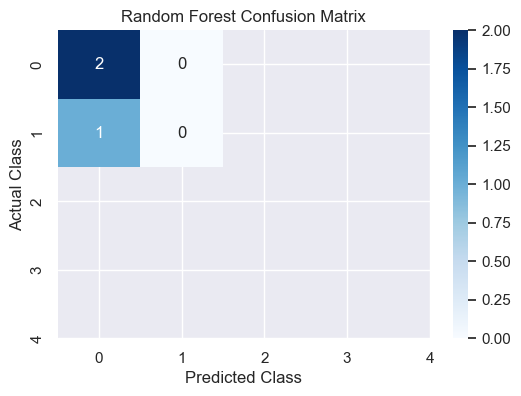

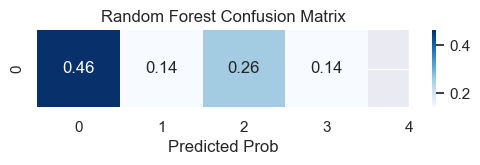

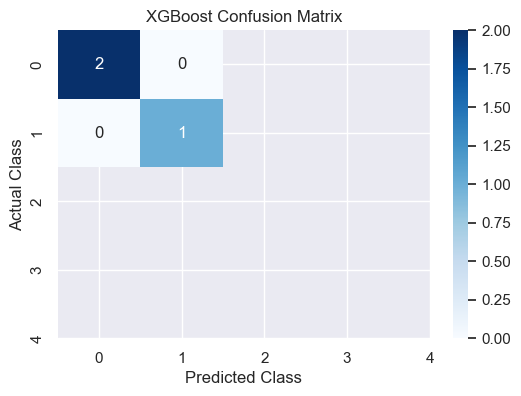

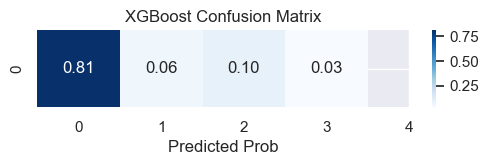

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

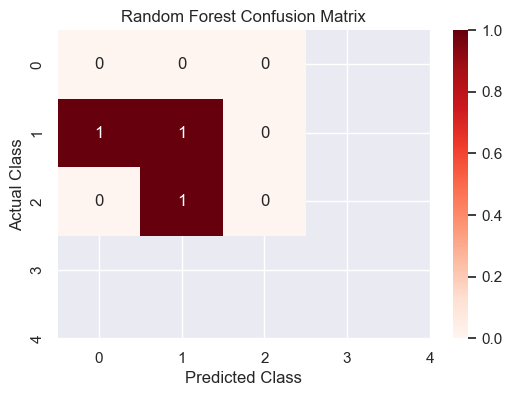

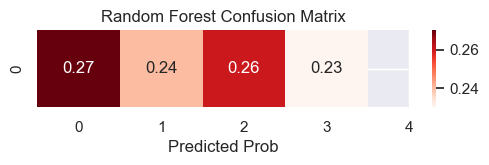

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got [1 2 3 4]

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

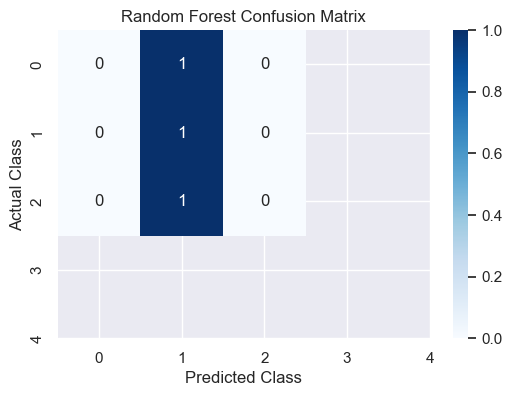

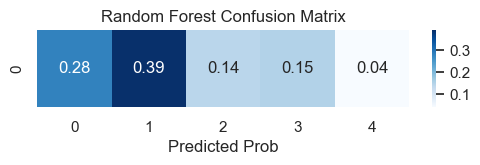

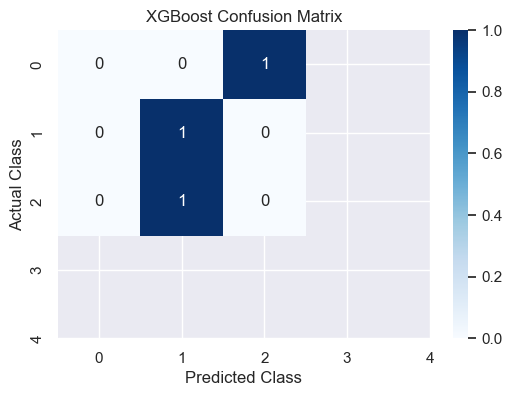

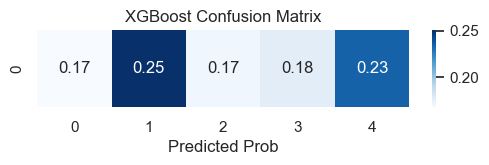

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

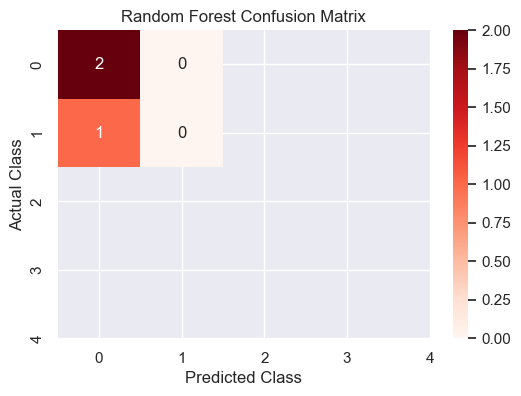

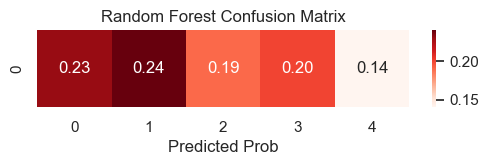

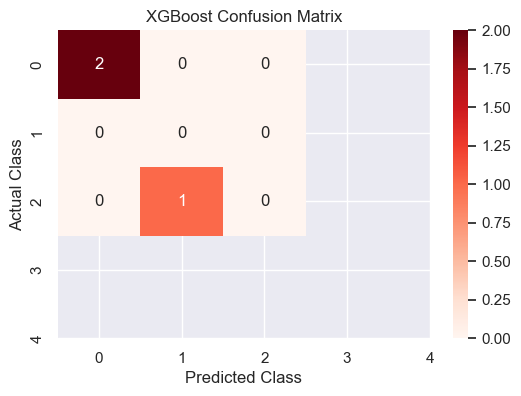

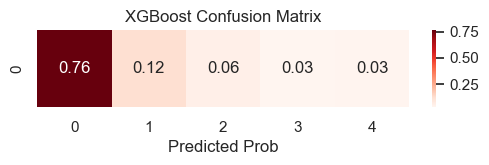

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

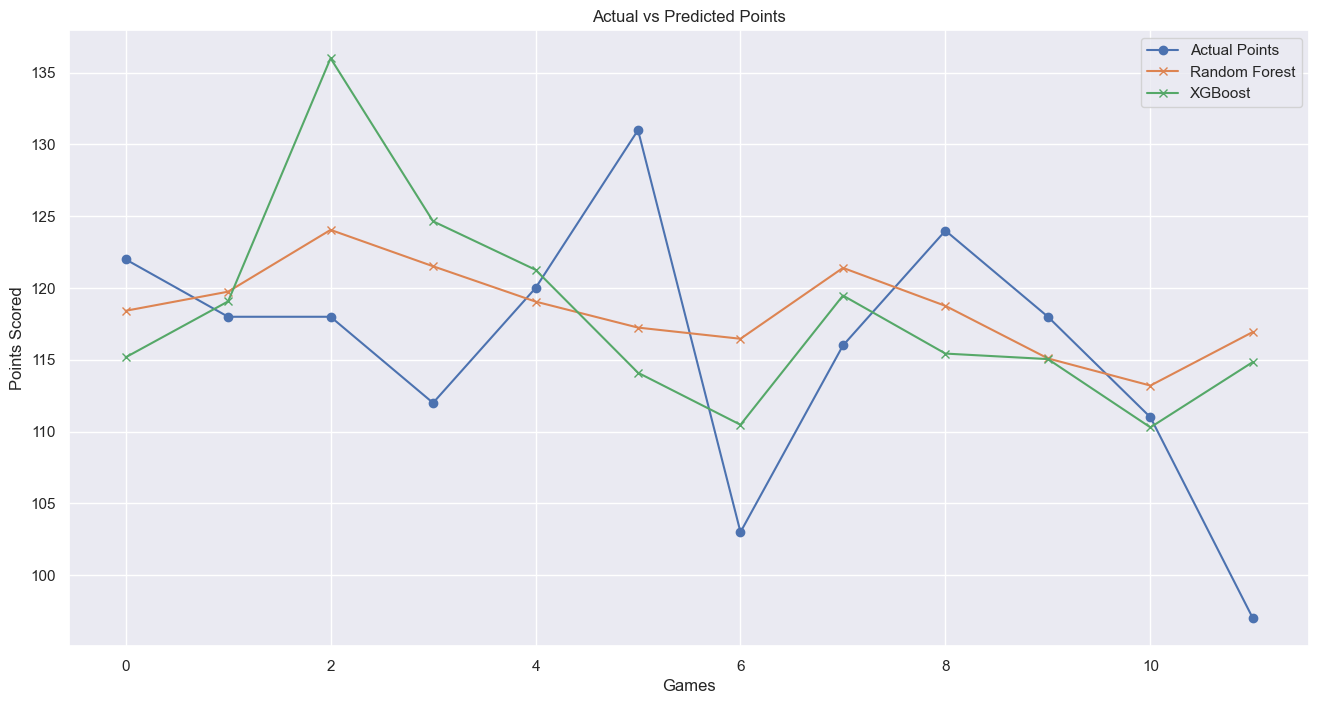

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
